# Phishing URL Detector
Trains a classifier on URL-based features to detect phishing sites.

**Pipeline:**
1. Load & merge two datasets
2. Extract 22 URL features via `feature_extract.py`
3. Train/test split → SMOTE → StandardScaler
4. Compare four models, optimising for **phishing recall**
5. Tune threshold via ROC + Youden's J
6. Save model to `phishing_model.pkl`


## 1. Imports

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from feature_extract import extract_features, FEATURE_NAMES

## 2. Load & Merge Datasets

In [2]:
df = pd.read_csv("phishing_site_urls.csv")
df = df.rename(columns={"URL": "url", "Label": "label"})
df["label"] = df["label"].map({"bad": 1, "good": 0})

df = (
    df.drop_duplicates(subset="url")
    .dropna(subset=["label"])
    .reset_index(drop=True)
)

df = df[df["url"].str.len() > 10]
df = df[df["url"].str.contains(r"\.", regex=True)]

print(f"Dataset shape: {df.shape}")
print(df["label"].value_counts())

## 3. Feature Extraction

Features are extracted via `feature_extract.py` — imported above.
This keeps training and inference in sync automatically.

In [3]:
feature_matrix = df["url"].apply(extract_features).tolist()
X = pd.DataFrame(feature_matrix, columns=FEATURE_NAMES)
y = df["label"]

print(X.shape)
X.head()

(516467, 22)


,suspicious_words,dots,hyphens,path_len,domain_digits,domain_len,domain_entropy,num_params,is_shortened,has_ip,...,subdomains,https,prefix_suffix,redirect,abnormal_www,double_slash,special_chars,suspicious_tld,brand,free_ddns
0,0,3,0,11,0,19,3.195296,0,0,0,...,2,0,0,0,0,0,3,0,0,0
1,0,1,0,47,0,23,3.708132,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,1,4,1,20,0,50,3.999080,3,0,0,...,4,1,1,0,0,0,9,0,1,0
3,0,2,0,0,0,11,3.095795,0,0,0,...,2,0,0,0,0,0,2,0,0,0
4,0,2,2,33,0,15,3.189898,0,0,0,...,2,0,0,0,0,0,4,0,0,0


## 4. Train / Test Split → SMOTE → Scaling

**Important ordering:** split first, then SMOTE only on the training set.
Doing SMOTE before splitting leaks synthetic samples into the test set.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Oversample minority class in training data only
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Scale — fit on training data only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Train: (634846, 22), Test: (103294, 22)
Train class balance: {0: 317423, 1: 317423}


## 5. Model Comparison

Four models compared. Threshold is tuned to maximise **phishing F1 (class 1)** — 
not overall F1. For a security tool, missing phishing is more dangerous than a false alarm.
XGBoost uses `scale_pos_weight=5` to tell the model phishing errors cost 5x more.


In [5]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=25,
        min_samples_split=5, min_samples_leaf=2,
        class_weight="balanced", random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=5,   # phishing is the dangerous miss — weight it more
        min_child_weight=5,
        gamma=0.1,
        random_state=42,
        eval_metric="logloss",
    ),
}

thresholds = np.arange(0.1, 0.9, 0.05)
results = {}

for name, clf in candidates.items():
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # Optimise threshold for phishing F1 (class 1), not overall F1
    # Missing phishing is more dangerous than a false alarm
    scores = [f1_score(y_test, (y_prob > t).astype(int), pos_label=1) for t in thresholds]
    best_t = thresholds[np.argmax(scores)]
    y_pred = (y_prob > best_t).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1  = max(scores)
    results[name] = {"f1": f1, "acc": acc, "threshold": best_t}

    print(f"\n{'='*40}")
    print(f"{name}  |  threshold={best_t:.2f}  |  acc={acc:.4f}  |  phishing-f1={f1:.4f}")
    print(classification_report(y_test, y_pred))

# Pick winner by phishing F1 (class 1)
best_model_name = max(results, key=lambda k: results[k]["f1"])
print(f"\n✅ Best model: {best_model_name} (phishing F1={results[best_model_name]['f1']:.4f})")



Logistic Regression  |  threshold=0.55  |  acc=0.8006  |  phishing-f1=0.5361
              precision    recall  f1-score   support

           0       0.85      0.89      0.87     79356
           1       0.58      0.50      0.54     23938

    accuracy                           0.80    103294
   macro avg       0.72      0.69      0.70    103294
weighted avg       0.79      0.80      0.79    103294


Random Forest  |  threshold=0.60  |  acc=0.8464  |  phishing-f1=0.6294
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     79356
           1       0.71      0.56      0.63     23938

    accuracy                           0.85    103294
   macro avg       0.79      0.75      0.77    103294
weighted avg       0.84      0.85      0.84    103294


Gradient Boosting  |  threshold=0.60  |  acc=0.8335  |  phishing-f1=0.5900
              precision    recall  f1-score   support

           0       0.86      0.93      0.90     79356
           

## 6. Final Model — Threshold Tuning via ROC / Youden's J

Youden's J (TPR − FPR) gives a principled threshold that balances
sensitivity and specificity, rather than just maximising F1 on one split.

Best threshold (Youden's J): 0.4827
ROC AUC: 0.8569


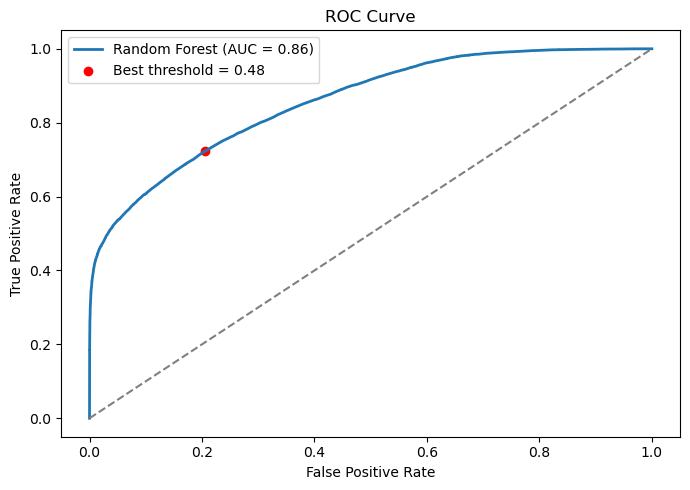

In [6]:
final_model = candidates[best_model_name]
y_prob = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

best_idx       = (tpr - fpr).argmax()
best_threshold = roc_thresholds[best_idx]

print(f"Best threshold (Youden's J): {best_threshold:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ROC curve plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"{best_model_name} (AUC = {roc_auc:.2f})")
plt.scatter(fpr[best_idx], tpr[best_idx], marker="o", color="red",
            label=f"Best threshold = {best_threshold:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
y_pred = (y_prob > best_threshold).astype(int)
print(f"Final accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Final accuracy : 0.7783
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     79356
           1       0.52      0.72      0.60     23938

    accuracy                           0.78    103294
   macro avg       0.71      0.76      0.72    103294
weighted avg       0.81      0.78      0.79    103294



## 7. Feature Importance

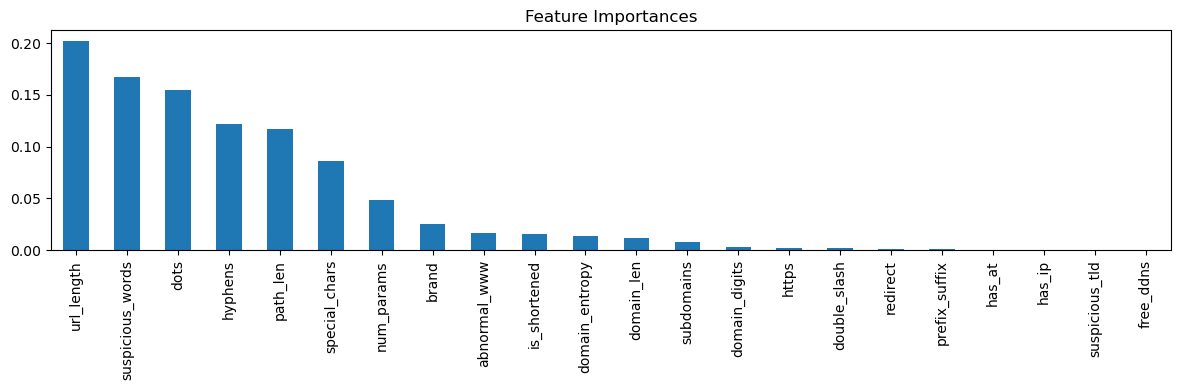

url_length          0.202214
suspicious_words    0.167245
dots                0.155080
hyphens             0.121947
path_len            0.117057
special_chars       0.085839
num_params          0.049003
brand               0.025697
abnormal_www        0.016786
is_shortened        0.015631
domain_entropy      0.013629
domain_len          0.011780
subdomains          0.008081
domain_digits       0.002724
https               0.002641
double_slash        0.001757
redirect            0.001584
prefix_suffix       0.000817
has_at              0.000363
has_ip              0.000077
suspicious_tld      0.000047
free_ddns           0.000001
dtype: float64


In [8]:
importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_NAMES
).sort_values(ascending=False)

importance.plot(kind="bar", figsize=(12, 4), title="Feature Importances")
plt.tight_layout()
plt.show()

print(importance)

## 8. Save Model

In [10]:
model_data = {
    "model":     final_model,
    "scaler":    scaler,
    "threshold": best_threshold,
    "features":  FEATURE_NAMES,
}

with open("phishing_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Saved → phishing_model.pkl")
print(f"Model : {final_model}")
print(f"Threshold: {best_threshold:.4f}")

Saved → phishing_model.pkl
Model : RandomForestClassifier(class_weight='balanced', max_depth=25,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)
Threshold: 0.4827


In [11]:
import pickle
with open("phishing_model.pkl", "rb") as f:
    saved = pickle.load(f)

print("Features model was trained on:", len(saved["features"]))
print(saved["features"])

Features model was trained on: 22
['suspicious_words', 'dots', 'hyphens', 'path_len', 'domain_digits', 'domain_len', 'domain_entropy', 'num_params', 'is_shortened', 'has_ip', 'has_at', 'url_length', 'subdomains', 'https', 'prefix_suffix', 'redirect', 'abnormal_www', 'double_slash', 'special_chars', 'suspicious_tld', 'brand', 'free_ddns']


In [12]:
import sys
sys.path.insert(0, '.')
from feature_extract import FEATURE_NAMES
print(len(FEATURE_NAMES))
print(FEATURE_NAMES)

22
['suspicious_words', 'dots', 'hyphens', 'path_len', 'domain_digits', 'domain_len', 'domain_entropy', 'num_params', 'is_shortened', 'has_ip', 'has_at', 'url_length', 'subdomains', 'https', 'prefix_suffix', 'redirect', 'abnormal_www', 'double_slash', 'special_chars', 'suspicious_tld', 'brand', 'free_ddns']
